In [1]:
!pip install -q transformers torchvision albumentations

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [3]:
!git clone https://github.com/tangsanli5201/DeepPCB.git

Cloning into 'DeepPCB'...
remote: Enumerating objects: 4753, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4753 (delta 13), reused 12 (delta 12), pack-reused 4739 (from 1)
Receiving objects: 100% (4753/4753), 85.81 MiB | 21.21 MiB/s, done.
Resolving deltas: 100% (191/191), done.
Updating files: 100% (4548/4548), done.


In [32]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset


class DeepPCBDataset(Dataset):
    def __init__(self, root_dir, split_file):
        self.root_dir = root_dir

        with open(split_file, "r") as f:
            self.samples = [line.strip().split() for line in f.readlines()]

        self.classes = ["defect"]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_rel_path, ann_rel_path = self.samples[idx]

        img_path = os.path.join(
            self.root_dir,
            img_rel_path.replace(".jpg", "_test.jpg")
        )
        ann_path = os.path.join(self.root_dir, ann_rel_path)

        image = Image.open(img_path).convert("RGB")
        img_w, img_h = image.size

        boxes = []
        labels = []

        if os.path.exists(ann_path):
            with open(ann_path, "r") as f:
                for line in f:
                    parts = line.strip().split()

                    if len(parts) < 5:
                        continue

                    # xmin ymin xmax ymax clase
                    xmin, ymin, xmax, ymax = map(float, parts[0:4])
                    label = int(parts[4])

                    # clamp
                    xmin = max(0, min(xmin, img_w))
                    ymin = max(0, min(ymin, img_h))
                    xmax = max(0, min(xmax, img_w))
                    ymax = max(0, min(ymax, img_h))

                    # asegurar orden
                    xmin, xmax = sorted([xmin, xmax])
                    ymin, ymax = sorted([ymin, ymax])

                    # descartar basura
                    if (xmax - xmin) < 1 or (ymax - ymin) < 1:
                        continue

                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(0)  # todo como "defect"

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "class_labels": torch.tensor(labels, dtype=torch.int64)
        }

        return image, target

In [33]:
ROOT_DIR = "/content/DeepPCB/PCBData"
SPLIT_FILE = "/content/DeepPCB/PCBData/trainval.txt"

dataset = DeepPCBDataset(ROOT_DIR, SPLIT_FILE)

print("Samples:", len(dataset))
print("Clases:", dataset.classes)

Samples: 1000
Clases: ['defect']


In [34]:
img, target = dataset[0]

print(img.size)
print(target)

(640, 640)
{'boxes': tensor([[409., 394., 435., 422.],
        [275., 383., 319., 417.],
        [  8., 163.,  36., 191.],
        [244., 151., 270., 182.],
        [338., 519., 364., 543.],
        [476., 460., 502., 481.]]), 'class_labels': tensor([0, 0, 0, 0, 0, 0])}


In [35]:
import torch
from torch.utils.data import random_split

# Fijar semilla para reproducibilidad
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 800
Test size: 200


In [36]:
import torch
from transformers import DetrForObjectDetection, DetrImageProcessor

# Processor
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

# Mapeo de clases (6 defectos)
id2label = {
    0: "open",
    1: "short",
    2: "mousebite",
    3: "spur",
    4: "copper",
    5: "pin-hole",
}

label2id = {v: k for k, v in id2label.items()}

# Modelo con 6 clases
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=6,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Modelo listo en:", device)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer1.0.downsam

Modelo listo en: cuda


In [9]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]

    encoding = processor(images=images, return_tensors="pt")

    return {
        "pixel_values": encoding["pixel_values"],
        "labels": targets
    }

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

print("Collate y loaders listos")

Collate y loaders listos


In [10]:
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

epochs = 50

for epoch in range(epochs):

    model.train()
    total_loss = 0.0

    for batch in train_loader:

        pixel_values = batch["pixel_values"].to(device)

        labels = [
            {k: v.to(device) for k, v in t.items()}
            for t in batch["labels"]
        ]

        outputs = model(
            pixel_values=pixel_values,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

Epoch 1/20 - Loss: 1283.7121
Epoch 2/20 - Loss: 932.3085
Epoch 3/20 - Loss: 784.9595
Epoch 4/20 - Loss: 754.2949
Epoch 5/20 - Loss: 724.4426
Epoch 6/20 - Loss: 710.0821
Epoch 7/20 - Loss: 703.6203
Epoch 8/20 - Loss: 699.2044
Epoch 9/20 - Loss: 694.6610
Epoch 10/20 - Loss: 692.2283
Epoch 11/20 - Loss: 682.9347
Epoch 12/20 - Loss: 681.5912
Epoch 13/20 - Loss: 678.5664
Epoch 14/20 - Loss: 677.5498
Epoch 15/20 - Loss: 687.2611
Epoch 16/20 - Loss: 679.3723
Epoch 17/20 - Loss: 672.4276
Epoch 18/20 - Loss: 672.8455
Epoch 19/20 - Loss: 670.1582
Epoch 20/20 - Loss: 669.0114


In [13]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

torch.save(model.state_dict(), "/content/drive/MyDrive/modelo_entrenado_vpc3.pth")

Mounted at /content/drive


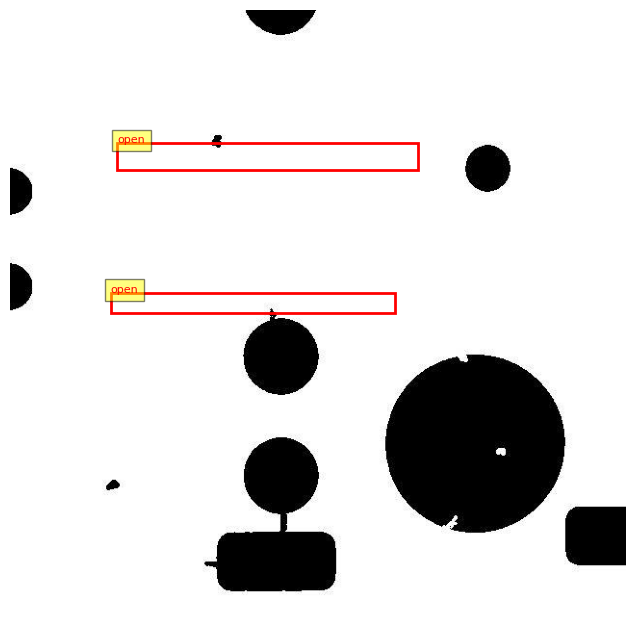

In [12]:
import torch
import matplotlib.pyplot as plt

model.eval()

# Tomar una muestra
image, target = dataset[10]

# DETR espera lista de imágenes
inputs = processor(images=[image], return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Post-processing correcto
results = processor.post_process_object_detection(
    outputs,
    target_sizes=[(image.size[1], image.size[0])],  # (h, w)
    threshold=0.5
)[0]

# Plot
plt.figure(figsize=(8, 8))
plt.imshow(image)

for score, label, box in zip(
    results["scores"],
    results["labels"],
    results["boxes"]
):
    xmin, ymin, xmax, ymax = box.cpu().numpy()

    plt.gca().add_patch(
        plt.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            edgecolor="red",
            linewidth=2
        )
    )

    plt.text(
        xmin,
        ymin,
        model.config.id2label[label.item()],
        color="red",
        fontsize=8,
        bbox=dict(facecolor="yellow", alpha=0.5)
    )

plt.axis("off")
plt.show()